In [8]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Display / plotting defaults
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110

RAW_DATA_PATH = Path("default of credit card clients - default of credit card clients.csv")
CLEAN_DATA_PATH = Path("cleaned_credit_data.csv")
DATA_DICTIONARY_PATH = Path("data_dictionary_cleaned.csv")

RANDOM_STATE = 42
print("Environment ready.")


Environment ready.


In [9]:
def load_raw_data(path: Path) -> pd.DataFrame:
    """Load the raw credit-card dataset exactly as supplied and validate its shape.

    The supplied CSV has a known non-standard layout: an extra generic
    ``X1, X2, ..., Y`` row precedes the real header row. ``header=1`` skips
    that artefact row and uses the true column names on row 2.

    Parameters
    ----------
    path : Path
        Location of the raw CSV file.

    Returns
    -------
    pd.DataFrame
        The raw, unmodified dataset (real column names, no artefact row).

    Raises
    ------
    FileNotFoundError
        If the file does not exist at the given path.
    AssertionError
        If the loaded shape does not match the documented 30,000 x 25 dataset.
    """
    if not path.exists():
        raise FileNotFoundError(f"Raw data file not found at: {path.resolve()}")

    df_raw = pd.read_csv(path, header=1)

    expected_rows, expected_cols = 30_000, 25
    assert df_raw.shape == (expected_rows, expected_cols), (
        f"Unexpected shape {df_raw.shape}; expected ({expected_rows}, {expected_cols}). "
        "Verify the source file matches the UCI 'Default of Credit Card Clients' dataset."
    )
    return df_raw


df_raw = load_raw_data(RAW_DATA_PATH)
print(f"Source file: {RAW_DATA_PATH.name}")
print(f"Loaded {df_raw.shape[0]:,} rows and {df_raw.shape[1]} columns.")
print(f"Row/column count matches UCI documentation: {df_raw.shape == (30000, 25)}")
df_raw.head()


Source file: default of credit card clients - default of credit card clients.csv
Loaded 30,000 rows and 25 columns.
Row/column count matches UCI documentation: True


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [10]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_1                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [11]:
df_raw.describe(include="all").T


,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_1,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [12]:
missing_summary = (
    df_raw.isnull()
    .sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda d: (d["missing_count"] / len(df_raw) * 100).round(3))
    .sort_values("missing_count", ascending=False)
)
print("Columns with missing values:", (missing_summary["missing_count"] > 0).sum())
missing_summary.head(10)


Columns with missing values: 0


,missing_count,missing_pct
ID,0,0.0
LIMIT_BAL,0,0.0
SEX,0,0.0
EDUCATION,0,0.0
MARRIAGE,0,0.0
AGE,0,0.0
PAY_1,0,0.0
PAY_2,0,0.0
PAY_3,0,0.0
PAY_4,0,0.0


In [13]:
print("Raw SEX codes:\n", df_raw["SEX"].value_counts(dropna=False), "\n")
print("Raw EDUCATION codes:\n", df_raw["EDUCATION"].value_counts(dropna=False), "\n")
print("Raw MARRIAGE codes:\n", df_raw["MARRIAGE"].value_counts(dropna=False), "\n")

pay_cols_raw = [c for c in df_raw.columns if c.startswith("PAY_") and not c.startswith("PAY_AMT")]
print("Repayment-status columns:", pay_cols_raw)
for c in pay_cols_raw:
    print(f"\n{c} value counts:\n", df_raw[c].value_counts().sort_index())


Raw SEX codes:
 SEX
2    18112
1    11888
Name: count, dtype: int64 

Raw EDUCATION codes:
 EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64 

Raw MARRIAGE codes:
 MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64 

Repayment-status columns: ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

PAY_1 value counts:
 PAY_1
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

PAY_2 value counts:
 PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

PAY_3 value counts:
 PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

PAY_4 value counts:
 PAY_4
-2     4348
-1     5687


In [14]:
def build_rename_map(columns: list[str]) -> dict[str, str]:
    """Construct a mapping from the supplied raw column names to clean snake_case names.

    Note: in the classic UCI export the most recent repayment-status column is
    named ``PAY_0``; in this project's supplied file it is already named
    ``PAY_1``, so no renumbering quirk needs to be handled here — we map it
    directly.
    """
    rename_map = {
        "ID": "customer_id",
        "LIMIT_BAL": "limit_balance",
        "SEX": "sex",
        "EDUCATION": "education",
        "MARRIAGE": "marriage",
        "AGE": "age",
        "default payment next month": "default_next_month",
    }

    # PAY_1..PAY_6 -> pay_status_1..pay_status_6
    for month in range(1, 7):
        rename_map[f"PAY_{month}"] = f"pay_status_{month}"

    for month in range(1, 7):
        rename_map[f"BILL_AMT{month}"] = f"bill_amount_{month}"
        rename_map[f"PAY_AMT{month}"] = f"pay_amount_{month}"

    missing = set(rename_map) - set(columns)
    if missing:
        raise KeyError(f"Expected raw columns not found in dataframe: {missing}")

    return rename_map


rename_map = build_rename_map(list(df_raw.columns))
df = df_raw.rename(columns=rename_map)

print("Renamed columns:")
print(list(df.columns))


Renamed columns:
['customer_id', 'limit_balance', 'sex', 'education', 'marriage', 'age', 'pay_status_1', 'pay_status_2', 'pay_status_3', 'pay_status_4', 'pay_status_5', 'pay_status_6', 'bill_amount_1', 'bill_amount_2', 'bill_amount_3', 'bill_amount_4', 'bill_amount_5', 'bill_amount_6', 'pay_amount_1', 'pay_amount_2', 'pay_amount_3', 'pay_amount_4', 'pay_amount_5', 'pay_amount_6', 'default_next_month']


In [15]:
SEX_LABELS = {1: "Male", 2: "Female"}

# Codes 0, 5, 6 are not defined in the UCI documentation (only 1-4 are documented).
EDUCATION_LABELS = {
    1: "Graduate School",
    2: "University",
    3: "High School",
    4: "Others",
    0: "Unknown/Other",
    5: "Unknown/Other",
    6: "Unknown/Other",
}

# Code 0 is not defined in the UCI documentation (only 1-3 are documented).
MARRIAGE_LABELS = {
    1: "Married",
    2: "Single",
    3: "Others",
    0: "Unknown/Other",
}


def decode_categoricals(frame: pd.DataFrame) -> pd.DataFrame:
    """Return a copy of ``frame`` with sex/education/marriage decoded to labels.

    Undocumented numeric codes are mapped to an explicit 'Unknown/Other' label
    (never dropped, never silently merged into a real category) so downstream
    consumers can see exactly how much of the portfolio has ambiguous
    demographic data.
    """
    out = frame.copy()

    out["sex_label"] = out["sex"].map(SEX_LABELS)
    out["education_label"] = out["education"].map(EDUCATION_LABELS)
    out["marriage_label"] = out["marriage"].map(MARRIAGE_LABELS)

    for col in ["sex_label", "education_label", "marriage_label"]:
        n_unmapped = out[col].isnull().sum()
        if n_unmapped:
            raise ValueError(f"{n_unmapped} unmapped codes remain in {col}; extend the mapping.")

    return out


df = decode_categoricals(df)

print("Education label distribution (post-decoding):")
print(df["education_label"].value_counts(), "\n")
print("Marriage label distribution (post-decoding):")
print(df["marriage_label"].value_counts(), "\n")

n_edu_unknown = (df["education_label"] == "Unknown/Other").sum()
n_mar_unknown = (df["marriage_label"] == "Unknown/Other").sum()
print(f"Accounts with undocumented education code: {n_edu_unknown} "
      f"({n_edu_unknown / len(df):.2%} of portfolio)")
print(f"Accounts with undocumented marriage code:  {n_mar_unknown} "
      f"({n_mar_unknown / len(df):.2%} of portfolio)")


Education label distribution (post-decoding):
education_label
University         14030
Graduate School    10585
High School         4917
Unknown/Other        345
Others               123
Name: count, dtype: int64 

Marriage label distribution (post-decoding):
marriage_label
Single           15964
Married          13659
Others             323
Unknown/Other       54
Name: count, dtype: int64 

Accounts with undocumented education code: 345 (1.15% of portfolio)
Accounts with undocumented marriage code:  54 (0.18% of portfolio)


In [16]:
def report_duplicates(frame: pd.DataFrame, id_col: str = "customer_id") -> dict:
    """Report full-row duplicates and duplicate customer IDs."""
    full_row_dupes = frame.duplicated(keep="first").sum()
    id_dupes = frame.duplicated(subset=[id_col], keep="first").sum()
    return {"full_row_duplicates": int(full_row_dupes), "duplicate_ids": int(id_dupes)}


dup_report_before = report_duplicates(df)
print("Duplicate check (before cleaning):", dup_report_before)

n_before = len(df)
df = df.drop_duplicates(keep="first").reset_index(drop=True)
df = df.drop_duplicates(subset=["customer_id"], keep="first").reset_index(drop=True)
n_after = len(df)

print(f"Rows removed as duplicates: {n_before - n_after} "
      f"({(n_before - n_after) / n_before:.3%} of the portfolio)")


Duplicate check (before cleaning): {'full_row_duplicates': 0, 'duplicate_ids': 0}
Rows removed as duplicates: 0 (0.000% of the portfolio)


In [17]:
def flag_invalid_age(frame: pd.DataFrame, min_age: int = 18, max_age: int = 100) -> pd.Series:
    """Return a boolean mask of ages outside a plausible adult credit-holder range."""
    return ~frame["age"].between(min_age, max_age)


def flag_invalid_pay_status(frame: pd.DataFrame) -> pd.Series:
    """Return a boolean mask of rows with a repayment-status code outside the
    documented range of -2 (no consumption) to 9 (>= 9 months delayed)."""
    pay_cols = [f"pay_status_{m}" for m in range(1, 7)]
    out_of_range = pd.DataFrame(
        {c: ~frame[c].between(-2, 9) for c in pay_cols}
    )
    return out_of_range.any(axis=1)


def flag_iqr_outliers(series: pd.Series, k: float = 3.0) -> pd.Series:
    """Return a boolean mask of extreme outliers using a wide (k=3) IQR fence.

    A wide fence (vs. the conventional k=1.5) is used deliberately: financial
    variables like credit limit are legitimately right-skewed, and we only
    want to flag genuinely extreme values for review, not the normal
    long tail of high-limit customers.
    """
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return ~series.between(lower, upper)


age_invalid_mask = flag_invalid_age(df)
pay_invalid_mask = flag_invalid_pay_status(df)
limit_outlier_mask = flag_iqr_outliers(df["limit_balance"])

print(f"Invalid ages (outside 18-100):        {age_invalid_mask.sum()}")
print(f"Invalid repayment-status codes:       {pay_invalid_mask.sum()}")
print(f"Extreme credit-limit outliers (IQR):  {limit_outlier_mask.sum()} "
      f"({limit_outlier_mask.mean():.2%} of portfolio)")


Invalid ages (outside 18-100):        0
Invalid repayment-status codes:       0
Extreme credit-limit outliers (IQR):  1 (0.00% of portfolio)


In [18]:
rows_before = len(df)

# Drop only the genuinely invalid records (impossible age or invalid repayment code).
invalid_mask = flag_invalid_age(df) | flag_invalid_pay_status(df)
df = df.loc[~invalid_mask].reset_index(drop=True)

rows_after = len(df)
print(f"Rows removed for invalid age/repayment-status: {rows_before - rows_after}")
print(f"Rows remaining after Phase 1 cleaning so far: {rows_after:,}")

# Persist the outlier flag rather than deleting extreme-but-valid records.
df["limit_balance_outlier_flag"] = flag_iqr_outliers(df["limit_balance"])


Rows removed for invalid age/repayment-status: 0
Rows remaining after Phase 1 cleaning so far: 30,000


In [19]:
PAY_STATUS_COLS = [f"pay_status_{m}" for m in range(1, 7)]
BILL_COLS = [f"bill_amount_{m}" for m in range(1, 7)]
PAY_AMT_COLS = [f"pay_amount_{m}" for m in range(1, 7)]


def add_average_bill_and_payment(frame: pd.DataFrame) -> pd.DataFrame:
    """Add 6-month average bill and average payment amounts."""
    out = frame.copy()
    out["avg_bill_amount"] = out[BILL_COLS].mean(axis=1)
    out["avg_pay_amount"] = out[PAY_AMT_COLS].mean(axis=1)
    return out


def add_payment_to_bill_ratio(frame: pd.DataFrame, epsilon: float = 1.0) -> pd.DataFrame:
    """Add a payment-to-bill ratio, guarded against division by zero/near-zero bills.

    Where the average bill is at or near zero (customer carried effectively no
    balance), the ratio is undefined from a repayment-capacity point of view;
    we cap the denominator at ``epsilon`` NTD so the ratio stays finite and we
    additionally clip the result to [0, 5] to prevent a handful of near-zero
    bills from producing absurd ratios that would distort later averages.
    """
    out = frame.copy()
    safe_denominator = out["avg_bill_amount"].abs().clip(lower=epsilon)
    raw_ratio = out["avg_pay_amount"] / safe_denominator
    out["payment_to_bill_ratio"] = raw_ratio.clip(lower=0, upper=5)
    return out


def add_delinquency_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Add count of delayed months and maximum delay across the 6-month window.

    A repayment-status value > 0 indicates a month of delinquency (1 = one
    month delayed, up to 9 = nine-plus months delayed). Values of -2/-1/0 all
    represent 'not delayed' states (no consumption / paid duly / revolving
    minimum payment) and are treated as zero delay.
    """
    out = frame.copy()
    delay_matrix = out[PAY_STATUS_COLS].clip(lower=0)
    out["num_months_delayed"] = (out[PAY_STATUS_COLS] > 0).sum(axis=1)
    out["max_delay_months"] = delay_matrix.max(axis=1)
    return out


def add_balance_trend(frame: pd.DataFrame) -> pd.DataFrame:
    """Add a recent-balance trend indicator: most-recent bill minus oldest bill.

    Positive values mean the outstanding balance has been growing over the
    6-month window (a warning sign); negative values mean it has been
    shrinking. Also adds a categorical version for easy grouping in EDA.
    """
    out = frame.copy()
    out["balance_trend"] = out["bill_amount_1"] - out["bill_amount_6"]

    conditions = [
        out["balance_trend"] > 0.05 * out["limit_balance"].clip(lower=1),
        out["balance_trend"] < -0.05 * out["limit_balance"].clip(lower=1),
    ]
    choices = ["Increasing", "Decreasing"]
    out["balance_trend_label"] = np.select(conditions, choices, default="Stable")
    return out


def add_utilisation_and_tiers(frame: pd.DataFrame) -> pd.DataFrame:
    """Add credit-utilisation ratio, credit-limit tiers, and age bands."""
    out = frame.copy()

    out["credit_utilisation"] = (
        out["bill_amount_1"] / out["limit_balance"].clip(lower=1)
    ).clip(lower=0, upper=3)

    out["limit_tier"] = pd.qcut(
        out["limit_balance"], q=4, labels=["Low", "Medium", "High", "Very High"]
    )

    age_bins = [17, 25, 35, 45, 55, 100]
    age_labels = ["18-25", "26-35", "36-45", "46-55", "56+"]
    out["age_band"] = pd.cut(out["age"], bins=age_bins, labels=age_labels)

    return out


def engineer_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Run the full Phase 1 feature-engineering pipeline in the documented order."""
    pipeline = (
        add_average_bill_and_payment,
        add_payment_to_bill_ratio,
        add_delinquency_features,
        add_balance_trend,
        add_utilisation_and_tiers,
    )
    out = frame
    for step in pipeline:
        out = step(out)
    return out


df = engineer_features(df)

engineered_cols = [
    "avg_bill_amount", "avg_pay_amount", "payment_to_bill_ratio",
    "num_months_delayed", "max_delay_months", "balance_trend",
    "balance_trend_label", "credit_utilisation", "limit_tier", "age_band",
]
df[engineered_cols].head(10)


,avg_bill_amount,avg_pay_amount,payment_to_bill_ratio,num_months_delayed,max_delay_months,balance_trend,balance_trend_label,credit_utilisation,limit_tier,age_band
0,1284.000000,114.833333,0.089434,2,2,3913,Increasing,0.195650,Low,18-25
1,2846.166667,833.333333,0.292791,2,2,-579,Stable,0.022350,Medium,26-35
2,16942.166667,1836.333333,0.108388,0,0,13690,Increasing,0.324878,Medium,26-35
3,38555.666667,1398.000000,0.036259,0,0,17443,Increasing,0.939800,Low,36-45
4,18223.166667,9841.500000,0.540054,0,0,-10514,Decreasing,0.172340,Low,56+
5,39685.666667,1295.333333,0.032640,0,0,44376,Increasing,1.288000,Low,36-45
6,454099.166667,30126.500000,0.066343,0,0,-105979,Decreasing,0.735930,Very High,26-35
7,2247.666667,798.500000,0.355257,0,0,11309,Increasing,0.118760,Medium,18-25
8,10868.666667,1126.833333,0.103677,1,2,7566,Increasing,0.080607,Medium,26-35
9,4486.500000,2354.833333,0.524871,0,0,-13912,Decreasing,0.000000,Low,26-35


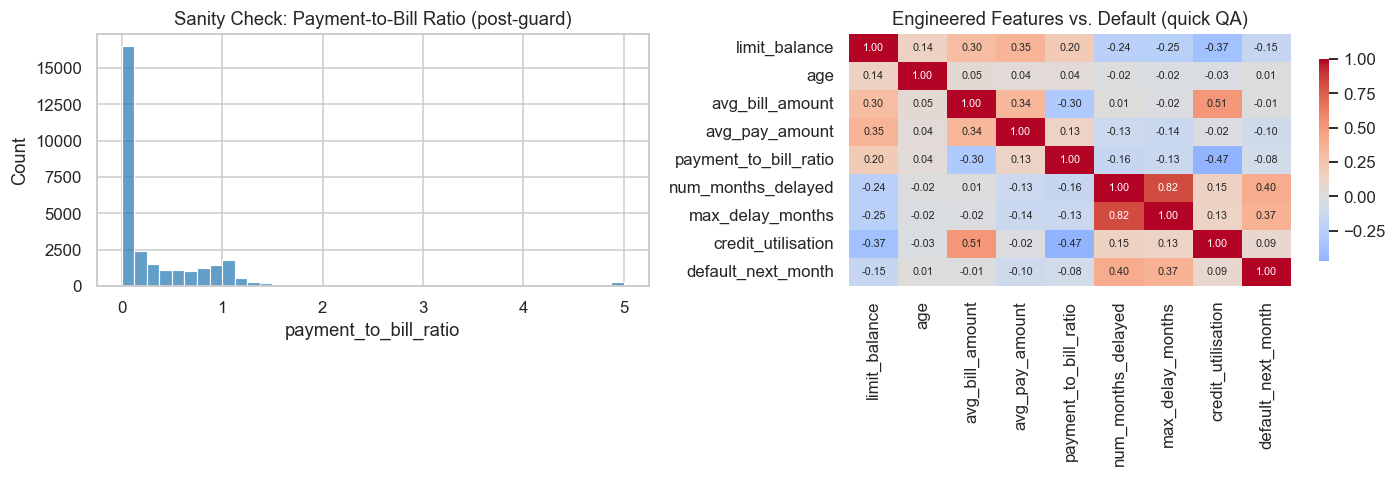

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["payment_to_bill_ratio"], bins=40, ax=axes[0], color="#2c7fb8")
axes[0].set_title("Sanity Check: Payment-to-Bill Ratio (post-guard)")
axes[0].set_xlabel("payment_to_bill_ratio")

corr_cols = [
    "limit_balance", "age", "avg_bill_amount", "avg_pay_amount",
    "payment_to_bill_ratio", "num_months_delayed", "max_delay_months",
    "credit_utilisation", "default_next_month",
]
corr = df[corr_cols].corr()
sns.heatmap(corr, ax=axes[1], cmap="coolwarm", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.8})
axes[1].set_title("Engineered Features vs. Default (quick QA)")

plt.tight_layout()
plt.show()


In [21]:
def final_quality_report(frame: pd.DataFrame) -> pd.DataFrame:
    """Produce a compact final data-quality summary for handover."""
    report = pd.DataFrame({
        "dtype": frame.dtypes.astype(str),
        "n_missing": frame.isnull().sum(),
        "pct_missing": (frame.isnull().mean() * 100).round(3),
        "n_unique": frame.nunique(),
    })
    return report


qa_report = final_quality_report(df)
print(f"Final cleaned shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Total missing values remaining: {int(df.isnull().sum().sum())}")
print(f"Remaining full-row duplicates: {df.duplicated().sum()}")
qa_report


Final cleaned shape: 30,000 rows x 39 columns
Total missing values remaining: 0
Remaining full-row duplicates: 0


,dtype,n_missing,pct_missing,n_unique
customer_id,int64,0,0.0,30000
limit_balance,int64,0,0.0,81
sex,int64,0,0.0,2
education,int64,0,0.0,7
marriage,int64,0,0.0,4
age,int64,0,0.0,56
pay_status_1,int64,0,0.0,11
pay_status_2,int64,0,0.0,11
pay_status_3,int64,0,0.0,11
pay_status_4,int64,0,0.0,11


In [22]:
df.to_csv(CLEAN_DATA_PATH, index=False)

qa_report.reset_index().rename(columns={"index": "column"}).to_csv(
    DATA_DICTIONARY_PATH, index=False
)

print(f"Cleaned dataset written to: {CLEAN_DATA_PATH.resolve()}")
print(f"Data dictionary written to: {DATA_DICTIONARY_PATH.resolve()}")
print(f"\nFinal dataset ready for Phase 2 (EDA): {df.shape[0]:,} rows x {df.shape[1]} columns")


Cleaned dataset written to: D:\NovaX--Group-project-of-Python-for-DS-AI\cleaned_credit_data.csv
Data dictionary written to: D:\NovaX--Group-project-of-Python-for-DS-AI\data_dictionary_cleaned.csv

Final dataset ready for Phase 2 (EDA): 30,000 rows x 39 columns


In [4]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

CLEAN_DATA_PATH = Path("cleaned_credit_data.csv")
ALPHA = 0.05  # significance level used throughout this notebook

print("Environment ready.")

Matplotlib is building the font cache; this may take a moment.


Environment ready.


In [5]:

def load_cleaned_data(path: Path) -> pd.DataFrame:
    """Load the Phase 1 cleaned dataset and verify it is analysis-ready.

    Parameters
    ----------
    path : Path
        Location of the cleaned CSV produced by the Data Engineer.

    Returns
    -------
    pd.DataFrame
        The cleaned, feature-engineered dataset.

    Raises
    ------
    FileNotFoundError
        If the file does not exist at the given path.
    AssertionError
        If the file still contains nulls, duplicate IDs, or is missing the
        target column — any of which would mean Phase 1 was not completed.
    """
    if not path.exists():
        raise FileNotFoundError(f"Cleaned data file not found at: {path.resolve()}")

    frame = pd.read_csv(path)

    assert frame.isnull().sum().sum() == 0, "Cleaned data still contains missing values."
    assert frame["customer_id"].is_unique, "Cleaned data still contains duplicate customer IDs."
    assert "default_next_month" in frame.columns, "Target column missing from cleaned data."

    return frame


df = load_cleaned_data(CLEAN_DATA_PATH)
print(f"Loaded cleaned dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Integrity checks passed: no nulls, no duplicate IDs, target column present.")
df.head(3)


Loaded cleaned dataset: 30,000 rows x 39 columns
Integrity checks passed: no nulls, no duplicate IDs, target column present.


,customer_id,limit_balance,sex,education,marriage,age,pay_status_1,pay_status_2,pay_status_3,pay_status_4,pay_status_5,pay_status_6,bill_amount_1,bill_amount_2,bill_amount_3,bill_amount_4,bill_amount_5,bill_amount_6,pay_amount_1,pay_amount_2,pay_amount_3,pay_amount_4,pay_amount_5,pay_amount_6,default_next_month,sex_label,education_label,marriage_label,limit_balance_outlier_flag,avg_bill_amount,avg_pay_amount,payment_to_bill_ratio,num_months_delayed,max_delay_months,balance_trend,balance_trend_label,credit_utilisation,limit_tier,age_band
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,Female,University,Married,False,1284.000000,114.833333,0.089434,2,2,3913,Increasing,0.195650,Low,18-25
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,Female,University,Single,False,2846.166667,833.333333,0.292791,2,2,-579,Stable,0.022350,Medium,26-35
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,Female,University,Single,False,16942.166667,1836.333333,0.108388,0,0,13690,Increasing,0.324878,Medium,26-35


In [6]:
def wilson_confidence_interval(successes: int, n: int, confidence: float = 0.95) -> tuple[float, float]:
    """Compute a Wilson score confidence interval for a binomial proportion.

    The Wilson interval is preferred over the naive normal-approximation
    interval because it stays within [0, 1] and remains accurate even for
    proportions far from 0.5, which is the case here (default rate ~22%).

    Parameters
    ----------
    successes : int
        Number of positive outcomes (defaults).
    n : int
        Total number of trials (accounts).
    confidence : float
        Confidence level, default 0.95.

    Returns
    -------
    tuple[float, float]
        Lower and upper bounds of the confidence interval.
    """
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    p_hat = successes / n
    denom = 1 + z ** 2 / n
    centre = p_hat + z ** 2 / (2 * n)
    margin = z * np.sqrt(p_hat * (1 - p_hat) / n + z ** 2 / (4 * n ** 2))
    return (centre - margin) / denom, (centre + margin) / denom


n_total = len(df)
n_default = int(df["default_next_month"].sum())
overall_rate = n_default / n_total
ci_low, ci_high = wilson_confidence_interval(n_default, n_total)

print(f"Portfolio size:            {n_total:,} accounts")
print(f"Defaulted next month:      {n_default:,} accounts")
print(f"Overall default rate:      {overall_rate:.2%}")
print(f"95% confidence interval:   [{ci_low:.2%}, {ci_high:.2%}]")


Portfolio size:            30,000 accounts
Defaulted next month:      6,636 accounts
Overall default rate:      22.12%
95% confidence interval:   [21.65%, 22.59%]


In [7]:
def segment_default_summary(frame: pd.DataFrame, group_col: str) -> pd.DataFrame:
    """Summarise account count, default count, default rate, and 95% CI by segment.

    Parameters
    ----------
    frame : pd.DataFrame
        The cleaned dataset.
    group_col : str
        Categorical column to group by (e.g. 'age_band', 'education_label').

    Returns
    -------
    pd.DataFrame
        One row per segment level, sorted by default rate descending.
    """
    grouped = frame.groupby(group_col, observed=True)["default_next_month"].agg(
        n_accounts="count", n_default="sum"
    )
    grouped["default_rate"] = grouped["n_default"] / grouped["n_accounts"]

    ci_bounds = grouped.apply(
        lambda r: wilson_confidence_interval(int(r["n_default"]), int(r["n_accounts"])), axis=1
    )
    grouped["ci_low"] = ci_bounds.apply(lambda t: t[0])
    grouped["ci_high"] = ci_bounds.apply(lambda t: t[1])

    return grouped.sort_values("default_rate", ascending=False).reset_index()


def association_strength(frame: pd.DataFrame, group_col: str, target_col: str = "default_next_month") -> dict:
    """Run a chi-square test of independence and compute Cramer's V effect size.

    Returns
    -------
    dict
        chi2 statistic, p-value, degrees of freedom, and Cramer's V.
    """
    contingency = pd.crosstab(frame[group_col], frame[target_col])
    chi2, p_value, dof, _ = stats.chi2_contingency(contingency)
    n = contingency.to_numpy().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else np.nan
    return {"chi2": chi2, "p_value": p_value, "dof": dof, "cramers_v": cramers_v}


SEGMENT_COLS = ["age_band", "education_label", "marriage_label", "limit_tier"]

segment_summaries = {col: segment_default_summary(df, col) for col in SEGMENT_COLS}
association_results = pd.DataFrame(
    {col: association_strength(df, col) for col in SEGMENT_COLS}
).T
association_results.index.name = "segment"
association_results["significant_at_5pct"] = association_results["p_value"] < ALPHA

print("Statistical significance of each segment's association with default:\n")
association_results


Statistical significance of each segment's association with default:



,chi2,p_value,dof,cramers_v,significant_at_5pct
segment,,,,,
age_band,113.495433,1.307117e-23,4.0,0.061508,True
education_label,160.589153,1.092874e-33,4.0,0.073164,True
marriage_label,35.662396,8.825862e-08,3.0,0.034478,True
limit_tier,819.016214,3.250906e-177,3.0,0.165229,True


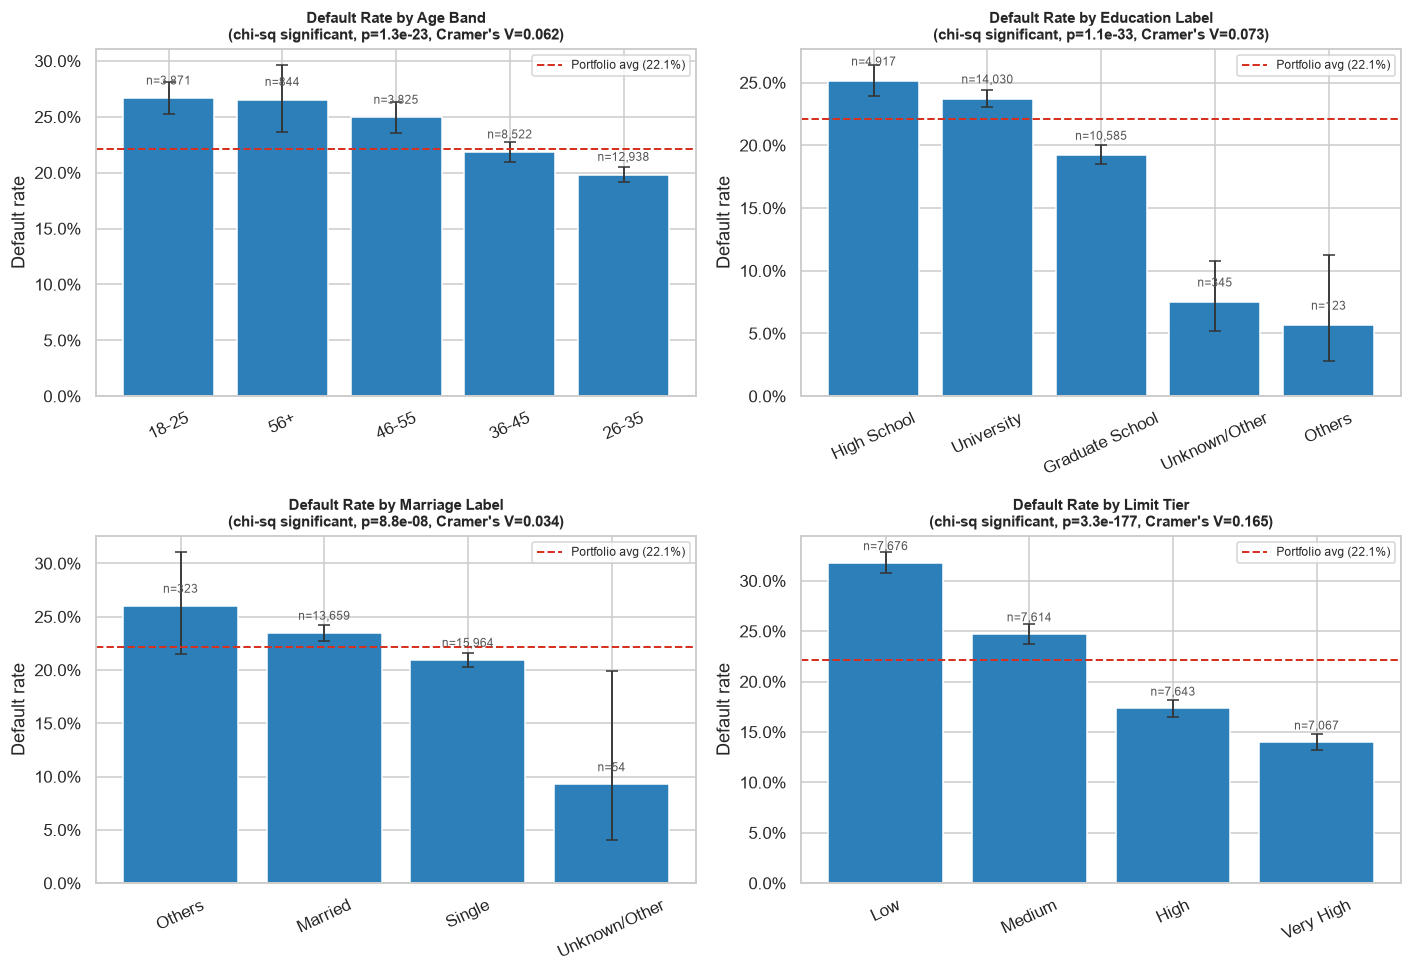

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

for ax, col in zip(axes, SEGMENT_COLS):
    summary = segment_summaries[col]
    bars = ax.bar(
        summary[col].astype(str), summary["default_rate"], color="#2c7fb8",
        yerr=[summary["default_rate"] - summary["ci_low"], summary["ci_high"] - summary["default_rate"]],
        capsize=4, error_kw={"linewidth": 1.2, "ecolor": "#333333"},
    )
    ax.axhline(overall_rate, color="#d7301f", linestyle="--", linewidth=1.3,
               label=f"Portfolio avg ({overall_rate:.1%})")
    for bar, n_acc in zip(bars, summary["n_accounts"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"n={n_acc:,}", ha="center", va="bottom", fontsize=8, color="#555555")

    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    p_val = association_results.loc[col, "p_value"]
    v = association_results.loc[col, "cramers_v"]
    sig_tag = "significant" if p_val < ALPHA else "not significant"
    ax.set_title(f"Default Rate by {col.replace('_', ' ').title()}\n"
                 f"(chi-sq {sig_tag}, p={p_val:.1e}, Cramer's V={v:.3f})", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Default rate")
    ax.tick_params(axis="x", rotation=25)
    ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()


In [9]:
delinquency_by_outcome = df.groupby("default_next_month", observed=True)[
    ["num_months_delayed", "max_delay_months"]
].agg(["mean", "median", "std"]).round(2)
delinquency_by_outcome.index = ["No Default", "Default"]
delinquency_by_outcome


num_months_delayed              max_delay_months             
                         mean median   std             mean median   std
No Default                0.5    0.0  1.15             0.47    0.0  0.90
Default                   2.0    1.0  2.13             1.43    2.0  1.29

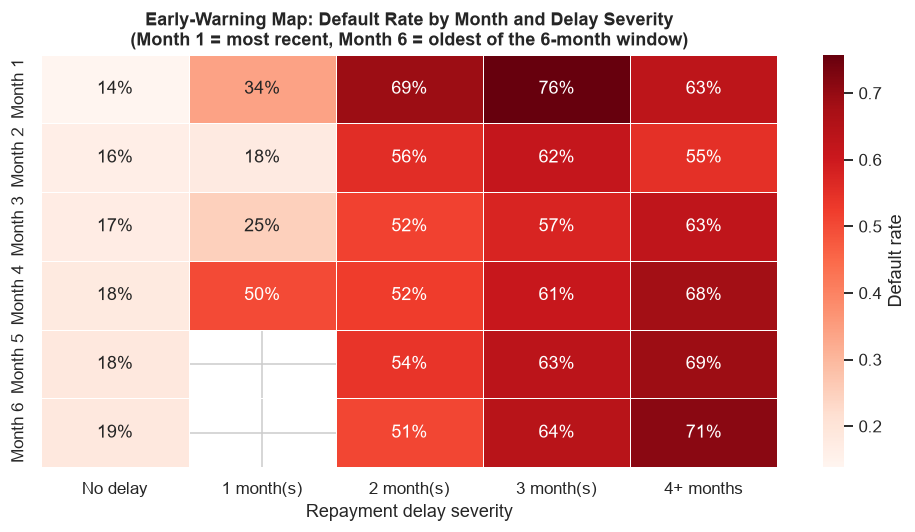

In [10]:
pay_status_cols = [f"pay_status_{m}" for m in range(1, 7)]

# Long-format table: one row per (customer, month, repayment status), for a month x severity view
long_pay = df.melt(
    id_vars=["customer_id", "default_next_month"],
    value_vars=pay_status_cols,
    var_name="month", value_name="pay_status",
)
long_pay["month"] = long_pay["month"].str.replace("pay_status_", "Month ", regex=False)

# Cap severity for a readable pivot: -2/-1/0 -> "No delay", 1..9 -> capped at 4+ for legibility
def bucket_severity(code: int) -> str:
    """Bucket a raw repayment-status code into a readable severity label."""
    if code <= 0:
        return "No delay"
    if code >= 4:
        return "4+ months"
    return f"{code} month(s)"


long_pay["severity"] = long_pay["pay_status"].apply(bucket_severity)

severity_order = ["No delay", "1 month(s)", "2 month(s)", "3 month(s)", "4+ months"]
pivot_default_rate = (
    long_pay.groupby(["month", "severity"], observed=True)["default_next_month"]
    .mean()
    .unstack("severity")
    .reindex(columns=severity_order)
    .reindex([f"Month {m}" for m in range(1, 7)])
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_default_rate, annot=True, fmt=".0%", cmap="Reds", ax=ax,
            cbar_kws={"label": "Default rate"}, linewidths=0.5, linecolor="white")
ax.set_title("Early-Warning Map: Default Rate by Month and Delay Severity\n"
              "(Month 1 = most recent, Month 6 = oldest of the 6-month window)")
ax.set_xlabel("Repayment delay severity")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


In [11]:
# Rank each month's raw repayment status by its point-biserial correlation with default —
# a direct, single-number measure of "how early-warning is this month's signal?"
correlation_by_month = []
for col in pay_status_cols:
    corr, p_val = stats.pointbiserialr(df["default_next_month"], df[col])
    correlation_by_month.append({"month": col, "correlation_with_default": corr, "p_value": p_val})

correlation_ranking = (
    pd.DataFrame(correlation_by_month)
    .sort_values("correlation_with_default", ascending=False)
    .reset_index(drop=True)
)
correlation_ranking


,month,correlation_with_default,p_value
0,pay_status_1,0.324794,0.000000e+00
1,pay_status_2,0.263551,0.000000e+00
2,pay_status_3,0.235253,0.000000e+00
3,pay_status_4,0.216614,1.899297e-315
4,pay_status_5,0.204149,1.126608e-279
5,pay_status_6,0.186866,7.296740e-234


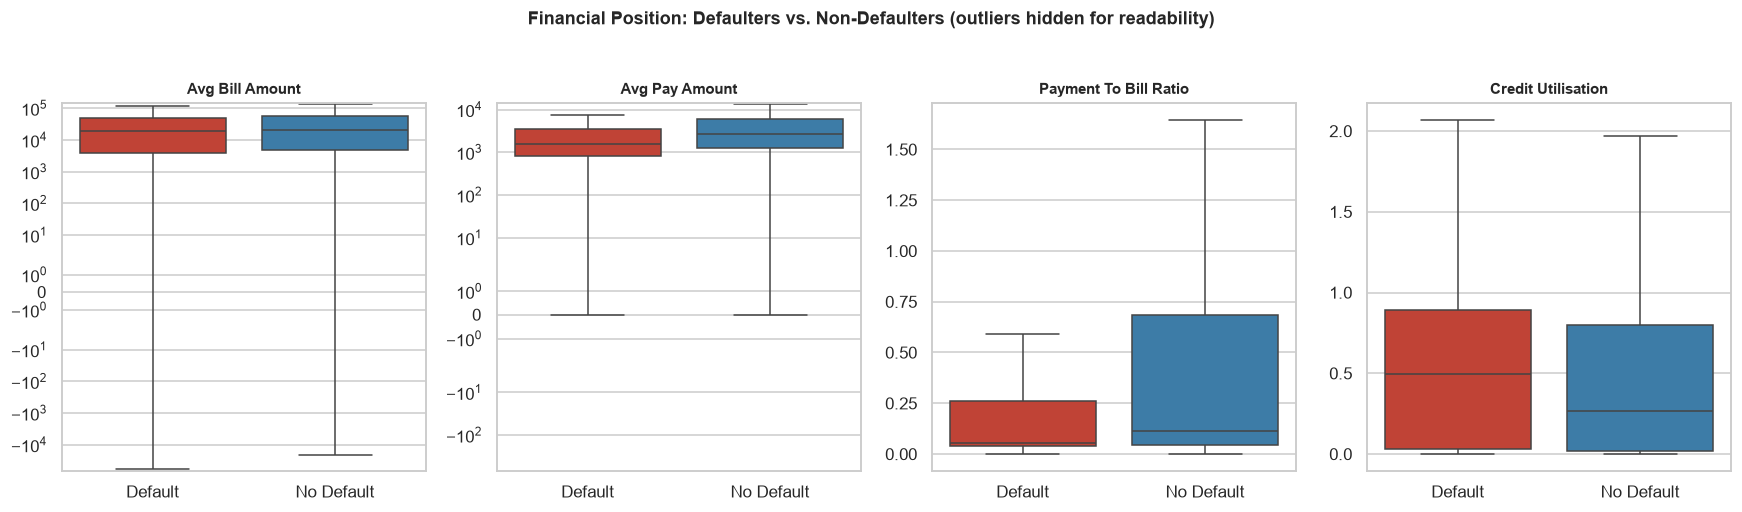

In [12]:
financial_cols = ["avg_bill_amount", "avg_pay_amount", "payment_to_bill_ratio", "credit_utilisation"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
outcome_labels = {0: "No Default", 1: "Default"}
plot_df = df.assign(outcome=df["default_next_month"].map(outcome_labels))

for ax, col in zip(axes, financial_cols):
    sns.boxplot(data=plot_df, x="outcome", y=col, hue="outcome", ax=ax,
                palette={"No Default": "#2c7fb8", "Default": "#d7301f"}, legend=False,
                showfliers=False)
    ax.set_title(col.replace("_", " ").title(), fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
    if col in ("avg_bill_amount", "avg_pay_amount"):
        ax.set_yscale("symlog")

plt.suptitle("Financial Position: Defaulters vs. Non-Defaulters (outliers hidden for readability)",
             y=1.03, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


In [13]:
def mann_whitney_effect_size(frame: pd.DataFrame, col: str, group_col: str = "default_next_month") -> dict:
    """Run a Mann-Whitney U test between the two outcome groups and compute
    the rank-biserial correlation as a distribution-free effect size.

    Returns
    -------
    dict
        U statistic, p-value, and rank-biserial correlation (-1 to 1).
    """
    group_0 = frame.loc[frame[group_col] == 0, col]
    group_1 = frame.loc[frame[group_col] == 1, col]
    u_stat, p_value = stats.mannwhitneyu(group_1, group_0, alternative="two-sided")
    rank_biserial = 1 - (2 * u_stat) / (len(group_0) * len(group_1))
    return {"U_statistic": u_stat, "p_value": p_value, "rank_biserial_corr": rank_biserial}


financial_test_results = pd.DataFrame(
    {col: mann_whitney_effect_size(df, col) for col in financial_cols}
).T
financial_test_results.index.name = "feature"
financial_test_results["significant_at_5pct"] = financial_test_results["p_value"] < ALPHA
financial_test_results


,U_statistic,p_value,rank_biserial_corr,significant_at_5pct
feature,,,,
avg_bill_amount,74628636.0,3.368955e-06,0.037320,True
avg_pay_amount,58744020.0,7.425614e-200,0.242225,True
payment_to_bill_ratio,62046827.0,2.168073e-136,0.199620,True
credit_utilisation,85340197.5,3.417572e-36,-0.100855,True


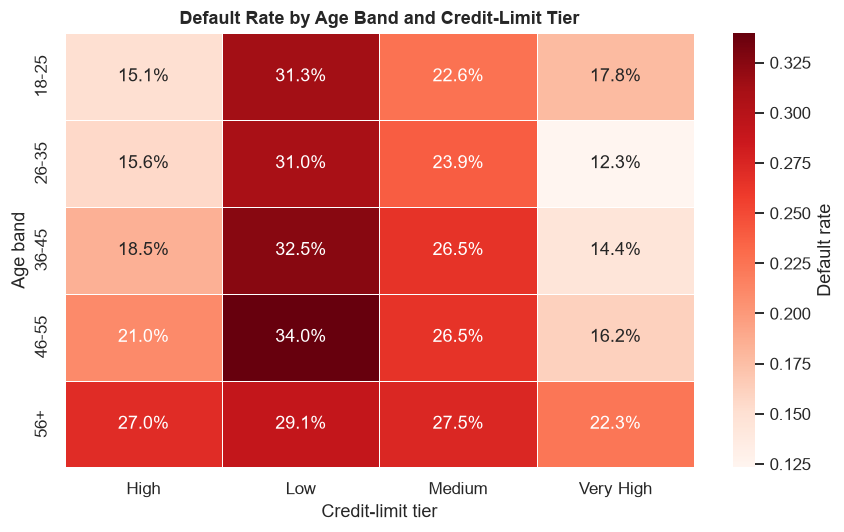

Underlying account counts per cell:


limit_tier,High,Low,Medium,Very High
age_band,,,,
18-25,372,2200,1181,118
26-35,3827,2371,3480,3260
36-45,2446,1697,1877,2502
46-55,824,1157,872,972
56+,174,251,204,215


In [14]:
cross_tab_rate = (
    df.pivot_table(index="age_band", columns="limit_tier", values="default_next_month",
                    aggfunc="mean", observed=True)
)
cross_tab_count = (
    df.pivot_table(index="age_band", columns="limit_tier", values="default_next_month",
                    aggfunc="count", observed=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(cross_tab_rate, annot=True, fmt=".1%", cmap="Reds", ax=ax,
            linewidths=0.5, linecolor="white", cbar_kws={"label": "Default rate"})
ax.set_title("Default Rate by Age Band and Credit-Limit Tier")
ax.set_xlabel("Credit-limit tier")
ax.set_ylabel("Age band")
plt.tight_layout()
plt.show()

print("Underlying account counts per cell:")
cross_tab_count


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# --- Consistent visual style for the whole portfolio ---
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12

# Consistent semantic colors used across every default-split chart
COLOR_NO_DEFAULT = "#4C72B0"   # steel blue  = did not default
COLOR_DEFAULT    = "#C44E52"   # red         = defaulted
PALETTE_DEFAULT  = {0: COLOR_NO_DEFAULT, 1: COLOR_DEFAULT}
SEQ_PALETTE      = "Blues"     # for single-variable magnitude charts

# Where exported report images will be saved
OUTPUT_DIR = "report_figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save_fig(fig, filename):
    """Save a figure to the report_figures/ folder at report quality."""
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, bbox_inches="tight", dpi=200)
    print(f"Saved: {path}")

print("Setup complete.")

Setup complete.


In [4]:
df = pd.read_csv("cleaned_credit_data.csv")

print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(f"Missing values remaining: {df.isnull().sum().sum()}")
df.head(3)

Rows: 30,000  |  Columns: 39
Missing values remaining: 0


,customer_id,limit_balance,sex,education,marriage,age,pay_status_1,pay_status_2,pay_status_3,pay_status_4,...,avg_bill_amount,avg_pay_amount,payment_to_bill_ratio,num_months_delayed,max_delay_months,balance_trend,balance_trend_label,credit_utilisation,limit_tier,age_band
0,1,20000,2,2,1,24,2,2,-1,-1,...,1284.000000,114.833333,0.089434,2,2,3913,Increasing,0.195650,Low,18-25
1,2,120000,2,2,2,26,-1,2,0,0,...,2846.166667,833.333333,0.292791,2,2,-579,Stable,0.022350,Medium,26-35
2,3,90000,2,2,2,34,0,0,0,0,...,16942.166667,1836.333333,0.108388,0,0,13690,Increasing,0.324878,Medium,26-35


In [5]:
# Confirm the categorical/engineered columns this notebook depends on are present
required_cols = [
    "default_next_month", "age_band", "education_label", "marriage_label",
    "limit_tier", "limit_balance", "payment_to_bill_ratio", "num_months_delayed",
    "credit_utilisation",
]
missing = [c for c in required_cols if c not in df.columns]
assert not missing, f"Missing expected columns from Phase 1 output: {missing}"
print("All required columns present.")

# Human-readable label for the binary target, used as the legend/axis label
# on every chart that splits by default outcome.
df["default_label"] = df["default_next_month"].map({0: "No Default", 1: "Default"})

All required columns present.


Saved: report_figures\01_overall_default_distribution.png


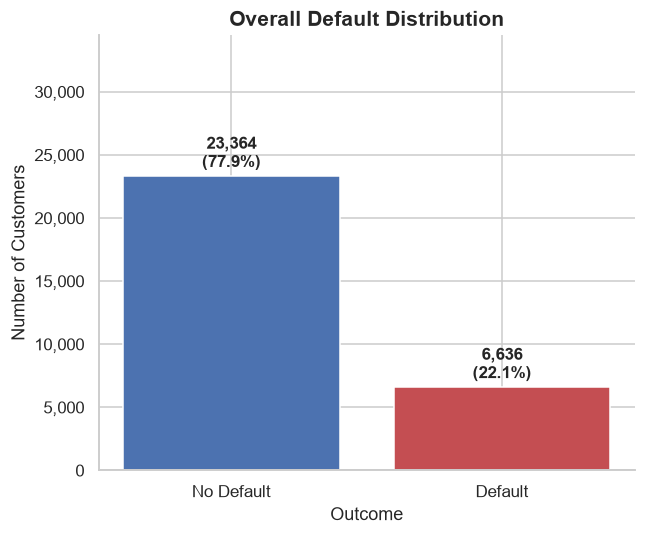

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))

counts = df["default_label"].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=[COLOR_NO_DEFAULT, COLOR_DEFAULT])

total = counts.sum()
for bar, value in zip(bars, counts.values):
    pct = value / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.01,
            f"{value:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title("Overall Default Distribution")
ax.set_xlabel("Outcome")
ax.set_ylabel("Number of Customers")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, total * 1.15)
sns.despine()
plt.tight_layout()
save_fig(fig, "01_overall_default_distribution.png")
plt.show()

Saved: report_figures\02_default_rate_by_age_band.png


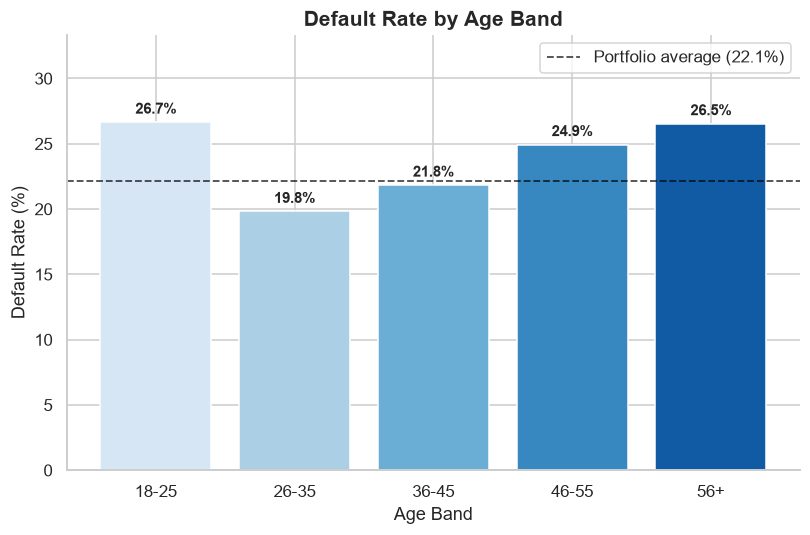

In [7]:
age_order = ["18-25", "26-35", "36-45", "46-55", "56+"]
age_default = df.groupby("age_band", observed=True)["default_next_month"].mean().reindex(age_order) * 100

fig, ax = plt.subplots(figsize=(7.5, 5))
bars = ax.bar(age_default.index, age_default.values, color=sns.color_palette(SEQ_PALETTE, len(age_default)))

overall_rate = df["default_next_month"].mean() * 100
ax.axhline(overall_rate, color="black", linestyle="--", linewidth=1.2, alpha=0.7,
           label=f"Portfolio average ({overall_rate:.1f}%)")

for bar, value in zip(bars, age_default.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f"{value:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Default Rate by Age Band")
ax.set_xlabel("Age Band")
ax.set_ylabel("Default Rate (%)")
ax.set_ylim(0, max(age_default.values) * 1.25)
ax.legend(loc="upper right", frameon=True)
sns.despine()
plt.tight_layout()
save_fig(fig, "02_default_rate_by_age_band.png")
plt.show()

Saved: report_figures\03_default_rate_by_education.png


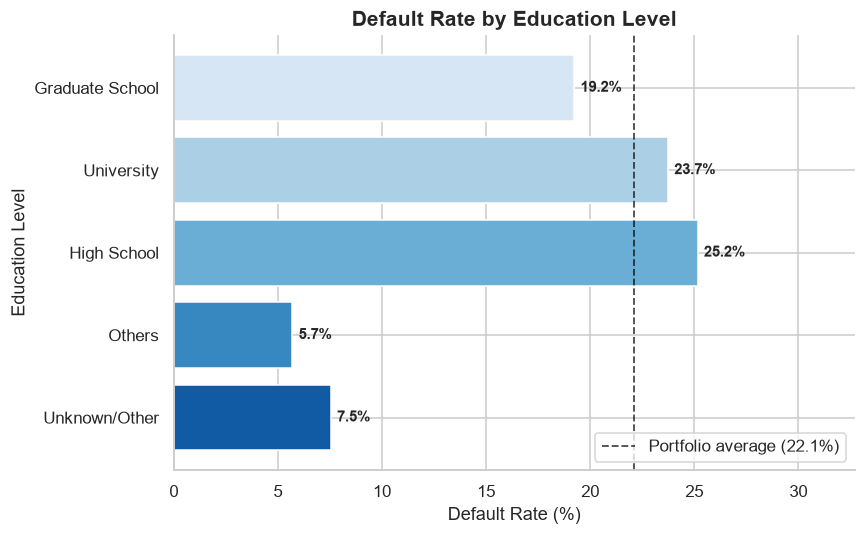

In [8]:
edu_order = ["Graduate School", "University", "High School", "Others", "Unknown/Other"]
edu_order = [e for e in edu_order if e in df["education_label"].unique()]
edu_default = df.groupby("education_label", observed=True)["default_next_month"].mean().reindex(edu_order) * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(edu_default.index[::-1], edu_default.values[::-1],
                color=sns.color_palette(SEQ_PALETTE, len(edu_default))[::-1])

ax.axvline(overall_rate, color="black", linestyle="--", linewidth=1.2, alpha=0.7,
           label=f"Portfolio average ({overall_rate:.1f}%)")

for bar, value in zip(bars, edu_default.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{value:.1f}%", va="center", fontsize=10, fontweight="bold")

ax.set_title("Default Rate by Education Level")
ax.set_xlabel("Default Rate (%)")
ax.set_ylabel("Education Level")
ax.set_xlim(0, max(edu_default.values) * 1.3)
ax.legend(loc="lower right", frameon=True)
sns.despine()
plt.tight_layout()
save_fig(fig, "03_default_rate_by_education.png")
plt.show()

Saved: report_figures\04_default_rate_by_marital_status.png


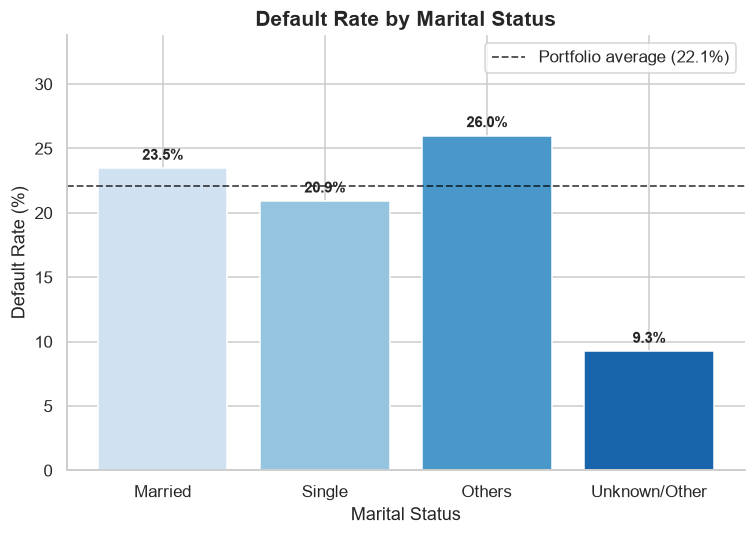

In [9]:
marriage_order = ["Married", "Single", "Others", "Unknown/Other"]
marriage_order = [m for m in marriage_order if m in df["marriage_label"].unique()]
marriage_default = df.groupby("marriage_label", observed=True)["default_next_month"].mean().reindex(marriage_order) * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(marriage_default.index, marriage_default.values,
              color=sns.color_palette(SEQ_PALETTE, len(marriage_default)))

ax.axhline(overall_rate, color="black", linestyle="--", linewidth=1.2, alpha=0.7,
           label=f"Portfolio average ({overall_rate:.1f}%)")

for bar, value in zip(bars, marriage_default.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f"{value:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Default Rate by Marital Status")
ax.set_xlabel("Marital Status")
ax.set_ylabel("Default Rate (%)")
ax.set_ylim(0, max(marriage_default.values) * 1.3)
ax.legend(loc="upper right", frameon=True)
sns.despine()
plt.tight_layout()
save_fig(fig, "04_default_rate_by_marital_status.png")
plt.show()

Saved: report_figures\05_default_rate_by_limit_tier.png


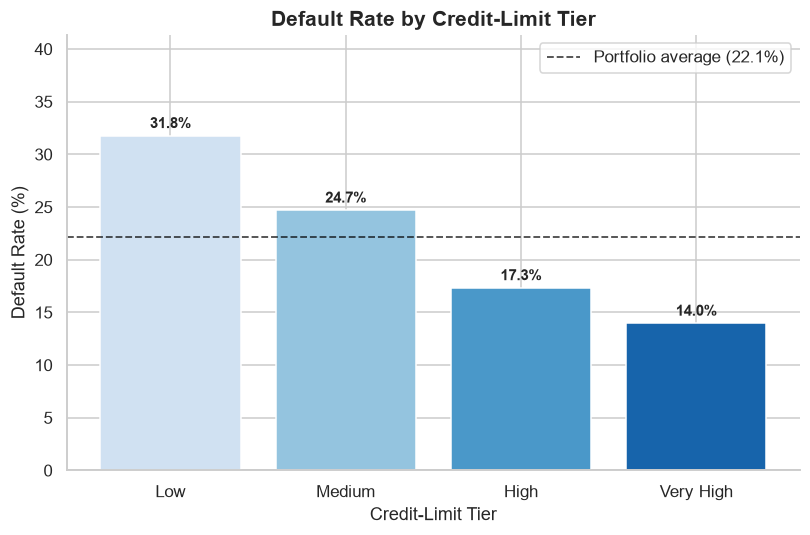

In [10]:
tier_order = ["Low", "Medium", "High", "Very High"]
tier_order = [t for t in tier_order if t in df["limit_tier"].unique()]
tier_default = df.groupby("limit_tier", observed=True)["default_next_month"].mean().reindex(tier_order) * 100

fig, ax = plt.subplots(figsize=(7.5, 5))
bars = ax.bar(tier_default.index, tier_default.values,
              color=sns.color_palette(SEQ_PALETTE, len(tier_default)))

ax.axhline(overall_rate, color="black", linestyle="--", linewidth=1.2, alpha=0.7,
           label=f"Portfolio average ({overall_rate:.1f}%)")

for bar, value in zip(bars, tier_default.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f"{value:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Default Rate by Credit-Limit Tier")
ax.set_xlabel("Credit-Limit Tier")
ax.set_ylabel("Default Rate (%)")
ax.set_ylim(0, max(tier_default.values) * 1.3)
ax.legend(loc="upper right", frameon=True)
sns.despine()
plt.tight_layout()
save_fig(fig, "05_default_rate_by_limit_tier.png")
plt.show()

Saved: report_figures\06_credit_limit_by_default.png


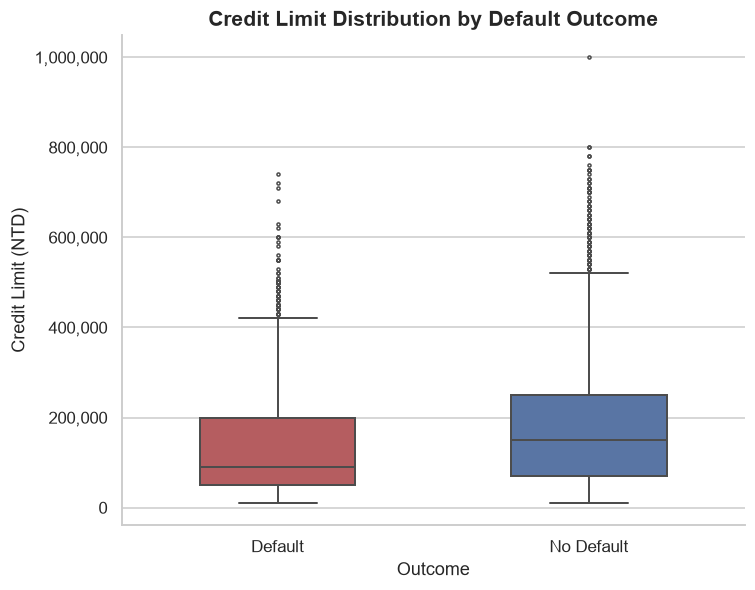

In [11]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.boxplot(data=df, x="default_label", y="limit_balance", hue="default_label",
            palette={"No Default": COLOR_NO_DEFAULT, "Default": COLOR_DEFAULT},
            legend=False, ax=ax, width=0.5, fliersize=2, linewidth=1.3)

ax.set_title("Credit Limit Distribution by Default Outcome")
ax.set_xlabel("Outcome")
ax.set_ylabel("Credit Limit (NTD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
sns.despine()
plt.tight_layout()
save_fig(fig, "06_credit_limit_by_default.png")
plt.show()

Saved: report_figures\07_payment_to_bill_ratio_by_default.png


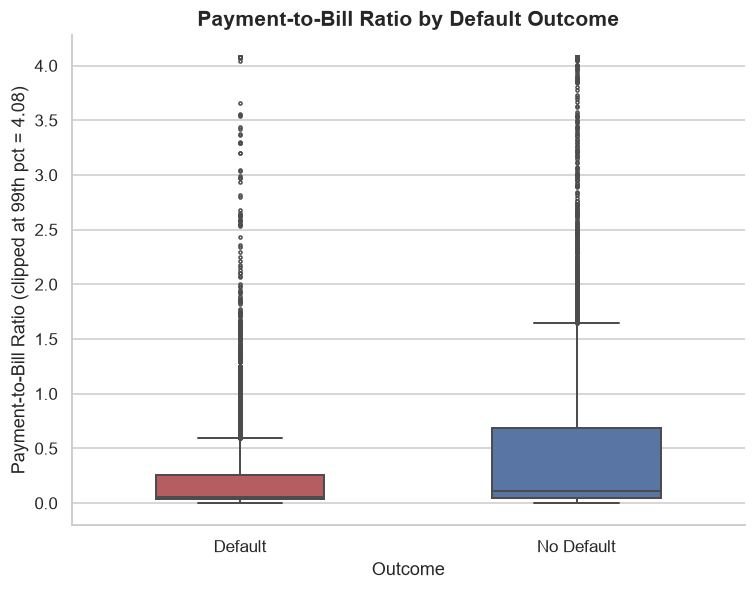

In [12]:
# Clip only for chart display so a handful of extreme outlier ratios don't
# compress the box for the other 99% of customers into an unreadable sliver.
clip_upper = df["payment_to_bill_ratio"].quantile(0.99)
plot_df = df.copy()
plot_df["payment_to_bill_ratio_display"] = plot_df["payment_to_bill_ratio"].clip(upper=clip_upper)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.boxplot(data=plot_df, x="default_label", y="payment_to_bill_ratio_display", hue="default_label",
            palette={"No Default": COLOR_NO_DEFAULT, "Default": COLOR_DEFAULT},
            legend=False, ax=ax, width=0.5, fliersize=2, linewidth=1.3)

ax.set_title("Payment-to-Bill Ratio by Default Outcome")
ax.set_xlabel("Outcome")
ax.set_ylabel(f"Payment-to-Bill Ratio (clipped at 99th pct = {clip_upper:.2f})")
sns.despine()
plt.tight_layout()
save_fig(fig, "07_payment_to_bill_ratio_by_default.png")
plt.show()

Saved: report_figures\08_default_rate_by_months_delayed.png


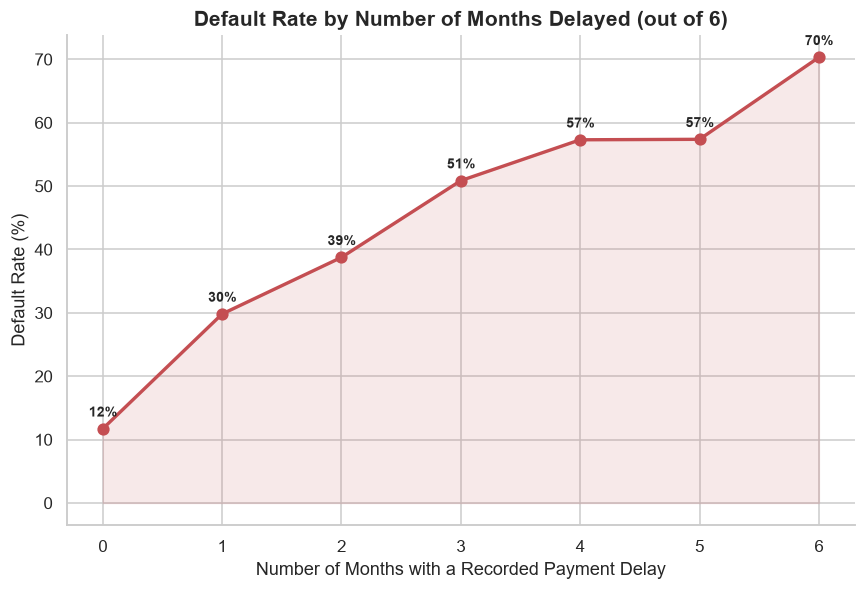

In [13]:
delay_default = df.groupby("num_months_delayed")["default_next_month"].agg(["mean", "count"])
delay_default = delay_default[delay_default["count"] >= 20]  # drop near-empty bins for a stable line
delay_default["rate_pct"] = delay_default["mean"] * 100

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(delay_default.index, delay_default["rate_pct"], marker="o", markersize=7,
        color=COLOR_DEFAULT, linewidth=2.2)
ax.fill_between(delay_default.index, delay_default["rate_pct"], color=COLOR_DEFAULT, alpha=0.12)

for x, y in zip(delay_default.index, delay_default["rate_pct"]):
    ax.annotate(f"{y:.0f}%", (x, y), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=9, fontweight="bold")

ax.set_title("Default Rate by Number of Months Delayed (out of 6)")
ax.set_xlabel("Number of Months with a Recorded Payment Delay")
ax.set_ylabel("Default Rate (%)")
ax.set_xticks(delay_default.index)
sns.despine()
plt.tight_layout()
save_fig(fig, "08_default_rate_by_months_delayed.png")
plt.show()

Saved: report_figures\09_credit_utilisation_by_default.png


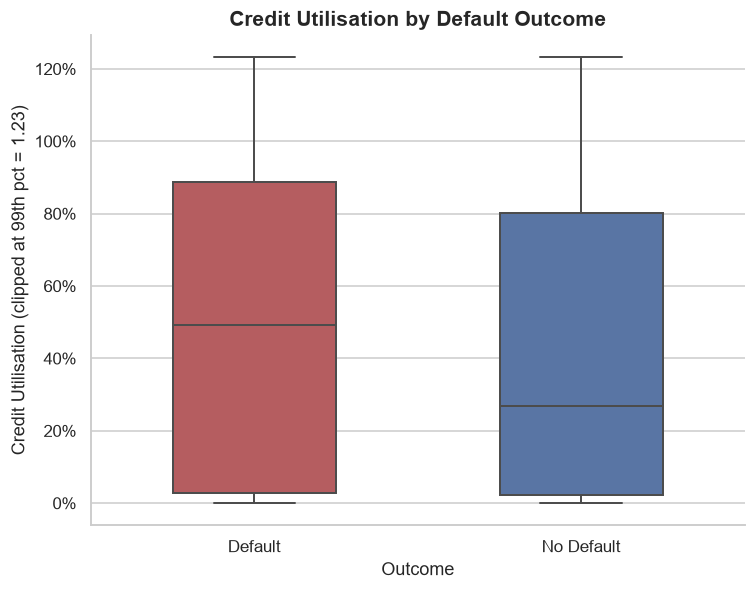

In [14]:
clip_util = df["credit_utilisation"].quantile(0.99)
plot_df["credit_utilisation_display"] = plot_df["credit_utilisation"].clip(upper=clip_util)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.boxplot(data=plot_df, x="default_label", y="credit_utilisation_display", hue="default_label",
            palette={"No Default": COLOR_NO_DEFAULT, "Default": COLOR_DEFAULT},
            legend=False, ax=ax, width=0.5, fliersize=2, linewidth=1.3)

ax.set_title("Credit Utilisation by Default Outcome")
ax.set_xlabel("Outcome")
ax.set_ylabel(f"Credit Utilisation (clipped at 99th pct = {clip_util:.2f})")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
sns.despine()
plt.tight_layout()
save_fig(fig, "09_credit_utilisation_by_default.png")
plt.show()

Saved: report_figures\10_correlation_heatmap.png


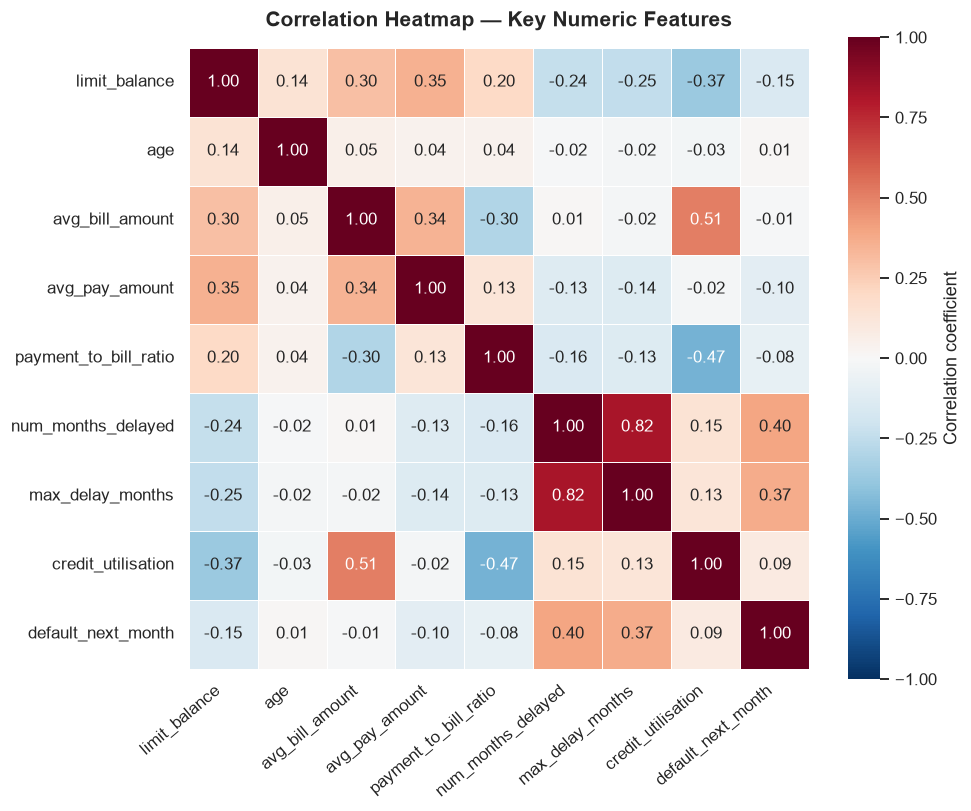

In [15]:
corr_features = [
    "limit_balance", "age", "avg_bill_amount", "avg_pay_amount",
    "payment_to_bill_ratio", "num_months_delayed", "max_delay_months",
    "credit_utilisation", "default_next_month",
]

corr_matrix = df[corr_features].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.6, linecolor="white",
    cbar_kws={"label": "Correlation coefficient"}, ax=ax,
)

ax.set_title("Correlation Heatmap — Key Numeric Features", pad=14)
plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
save_fig(fig, "10_correlation_heatmap.png")
plt.show()

In [16]:
exported = sorted(os.listdir(OUTPUT_DIR))
print(f"{len(exported)} figures exported to '{OUTPUT_DIR}/':\n")
for f in exported:
    print(f"  - {f}")

10 figures exported to 'report_figures/':

  - 01_overall_default_distribution.png
  - 02_default_rate_by_age_band.png
  - 03_default_rate_by_education.png
  - 04_default_rate_by_marital_status.png
  - 05_default_rate_by_limit_tier.png
  - 06_credit_limit_by_default.png
  - 07_payment_to_bill_ratio_by_default.png
  - 08_default_rate_by_months_delayed.png
  - 09_credit_utilisation_by_default.png
  - 10_correlation_heatmap.png


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# plot styling

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi'        : 120,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'figure.facecolor'  : 'white'
})

print("All libraries imported successfully.")
print(f"pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")



All libraries imported successfully.
pandas 3.0.0 | numpy 2.3.5 | seaborn 0.13.2


In [2]:
# Load cleaned dataset from Member 1

df = pd.read_csv('cleaned_credit_data.csv')

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"  Rows        : {df.shape[0]:,}")
print(f"  Columns     : {df.shape[1]}")
print(f"  Missing vals: {df.isnull().sum().sum()}")
print(f"  Default rate: {df['default_next_month'].mean():.2%}")
print(f"  Defaulted   : {df['default_next_month'].sum():,}")
print("=" * 55)
print()
print("Column list:")
print(df.columns.tolist())

DATASET OVERVIEW
  Rows        : 30,000
  Columns     : 39
  Missing vals: 0
  Default rate: 22.12%
  Defaulted   : 6,636

Column list:
['customer_id', 'limit_balance', 'sex', 'education', 'marriage', 'age', 'pay_status_1', 'pay_status_2', 'pay_status_3', 'pay_status_4', 'pay_status_5', 'pay_status_6', 'bill_amount_1', 'bill_amount_2', 'bill_amount_3', 'bill_amount_4', 'bill_amount_5', 'bill_amount_6', 'pay_amount_1', 'pay_amount_2', 'pay_amount_3', 'pay_amount_4', 'pay_amount_5', 'pay_amount_6', 'default_next_month', 'sex_label', 'education_label', 'marriage_label', 'limit_balance_outlier_flag', 'avg_bill_amount', 'avg_pay_amount', 'payment_to_bill_ratio', 'num_months_delayed', 'max_delay_months', 'balance_trend', 'balance_trend_label', 'credit_utilisation', 'limit_tier', 'age_band']


In [3]:
# Quick preview of key columns I will use

key_preview = ['customer_id', 'pay_status_1', 'pay_status_2',
               'num_months_delayed', 'max_delay_months',
               'payment_to_bill_ratio', 'credit_utilisation',
               'limit_balance', 'default_next_month']

print("Preview of key columns:")
df[key_preview].head(5)

Preview of key columns:


,customer_id,pay_status_1,pay_status_2,num_months_delayed,max_delay_months,payment_to_bill_ratio,credit_utilisation,limit_balance,default_next_month
0,1,2,2,2,2,0.089434,0.195650,20000,1
1,2,-1,2,2,2,0.292791,0.022350,120000,1
2,3,0,0,0,0,0.108388,0.324878,90000,0
3,4,0,0,0,0,0.036259,0.939800,50000,0
4,5,-1,0,0,0,0.540054,0.172340,50000,0


In [4]:
# Correlation with default_next_month

feature_cols = [
    'pay_status_1', 'pay_status_2', 'pay_status_3',
    'num_months_delayed', 'max_delay_months',
    'payment_to_bill_ratio', 'credit_utilisation',
    'limit_balance', 'avg_bill_amount', 'avg_pay_amount',
    'default_next_month'
]

corr_with_default = (df[feature_cols]
                     .corr()['default_next_month']
                     .drop('default_next_month')
                     .abs()
                     .sort_values(ascending=False))

print("=" * 55)
print("FEATURE CORRELATIONS WITH DEFAULT (|Pearson r|)")
print("=" * 55)
for feat, val in corr_with_default.items():
    bar = '█' * int(val * 30)
    print(f"  {feat:<25} {val:.4f}  {bar}")

print()
print(" Interpretation:")
print("  • pay_status_1 (most recent delay) → strongest signal")
print("  • num_months_delayed → how often customer delays")
print("  • payment_to_bill_ratio → how much they pay vs owe")
print("  • credit_utilisation → how much of limit they use")


FEATURE CORRELATIONS WITH DEFAULT (|Pearson r|)
  num_months_delayed        0.3984  ███████████
  max_delay_months          0.3704  ███████████
  pay_status_1              0.3248  █████████
  pay_status_2              0.2636  ███████
  pay_status_3              0.2353  ███████
  limit_balance             0.1535  ████
  avg_pay_amount            0.1024  ███
  credit_utilisation        0.0870  ██
  payment_to_bill_ratio     0.0805  ██
  avg_bill_amount           0.0127  

 Interpretation:
  • pay_status_1 (most recent delay) → strongest signal
  • num_months_delayed → how often customer delays
  • payment_to_bill_ratio → how much they pay vs owe
  • credit_utilisation → how much of limit they use


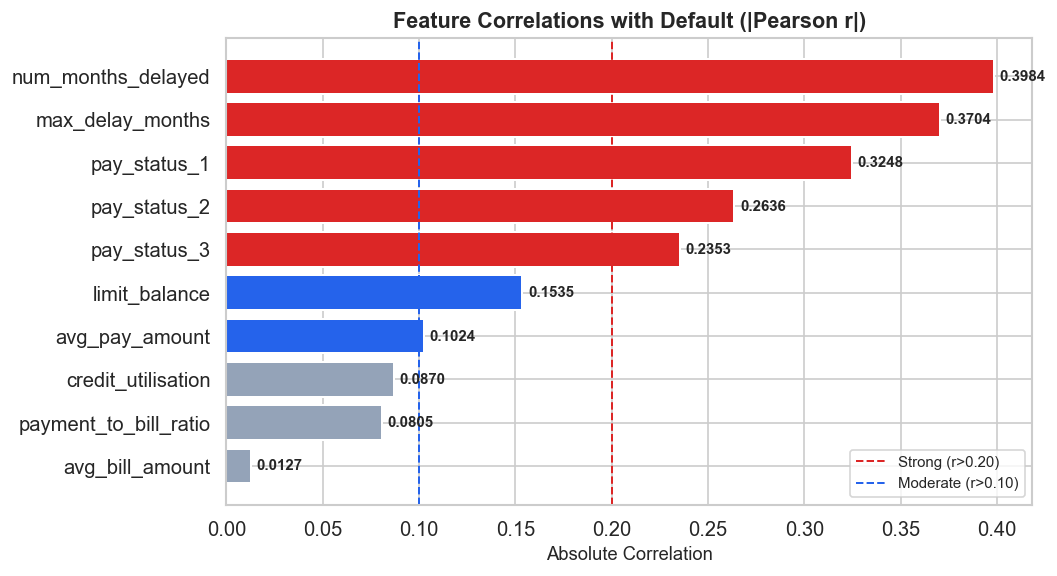

Saved: member4_correlations.png


In [5]:
# Visualize correlations

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#dc2626' if v > 0.20 else '#2563eb' if v > 0.10 else '#94a3b8'
          for v in corr_with_default.values]

bars = ax.barh(corr_with_default.index, corr_with_default.values,
               color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, corr_with_default.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

ax.set_title('Feature Correlations with Default (|Pearson r|)')
ax.set_xlabel('Absolute Correlation')
ax.axvline(0.20, color='#dc2626', ls='--', lw=1.2, label='Strong (r>0.20)')
ax.axvline(0.10, color='#2563eb', ls='--', lw=1.2, label='Moderate (r>0.10)')
ax.legend(fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('member4_correlations.png', bbox_inches='tight')
plt.show()
print("Saved: member4_correlations.png")


In [6]:
# DIMENSION 1: DELINQUENCY SCORE 
# Based on: num_months_delayed (how many months customer delayed)
# Rule-based pd.cut() because 0 delays has a specific meaning

df['delinquency_score'] = pd.cut(
    df['num_months_delayed'],
    bins=[-1, 0, 1, 3, 5, 6],
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Severe delay bonus: if max single delay >= 4 months → add +1
# This captures customers with extreme delays even if not frequent
severe_bonus = (df['max_delay_months'] >= 4).astype(int)
df['delinquency_score'] = (df['delinquency_score'] + severe_bonus).clip(upper=5)

print("DELINQUENCY SCORE distribution:")
print(df['delinquency_score'].value_counts().sort_index())
print()

# Validate: default rate should increase with delinquency score
val = df.groupby('delinquency_score')['default_next_month'].mean()
print("Default rate per delinquency score:")
for score, rate in val.items():
    print(f"  Score {score}: {rate:.2%}")


DELINQUENCY SCORE distribution:
delinquency_score
1    19931
2     4424
3     3018
4     1188
5     1439
Name: count, dtype: int64

Default rate per delinquency score:
  Score 1: 11.71%
  Score 2: 29.81%
  Score 3: 43.07%
  Score 4: 57.74%
  Score 5: 69.28%
